In [1]:
import sys
import glob
import torch
import math

sys.path.append('../utils/')
sys.path.append('../src/model/')

import MixtureMemoryModel
import encoders

sys.path.append('/om2/user/bjmedina/')

from chexture_choolbox.auditorytexture.statistics_sets import (
    STAT_SET_FULL_MCDERMOTTSIMONCELLI as statistics_dict
)
from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params

In [2]:
import glob
import torch
import sys
import numpy as np
from torch.utils.data import Dataset, DataLoader
from scipy.io import wavfile
from scipy import signal
from sklearn.decomposition import PCA

sys.path.append('/om2/user/bjmedina/')

from chexture_choolbox.auditorytexture.statistics_sets import (
    STAT_SET_FULL_MCDERMOTTSIMONCELLI as statistics_dict
)
from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params

import torch.nn as nn

import math

class MixtureMemoryModel(nn.Module):
    def __init__(self, encoding_model, noise_slope=1.0, noise_offset=1e-3, criterion=0.5, device='cpu'):
        super(MixtureMemoryModel, self).__init__()
        self.encoding_model = encoding_model
        self.noise_slope = noise_slope
        self.noise_offset = noise_offset
        self.criterion = criterion
        self.device = device
        self.memory_bank = []
        self.debug_mode = False


        self.probe_reps = []
        self.memory_snapshots = []
        self.decisions = []
        self.trial_indices = []
        self.probe_filenames = []
        self.filenames_seen = []
        
        # saving the value that led to a decision
        self.output = []

    def clear_memory(self):
        self.memory_bank = []
        self.probe_reps = []
        self.memory_snapshots = []
        self.decisions = []
        self.trial_indices = []
        self.filenames_seen = []
        self.probe_filenames = []

    def _toggle_debug(self):
        self.debug_mode = not self.debug_mode

        print(f"Debug flag is set to {self.debug_mode}")

    def encode_sound(self, sound):
        with torch.no_grad():
            return self.encoding_model(sound).squeeze(0)

    def gaussian_logpdf(self, x, mean, var):
        """Compute log probability density of x under N(mean, var) assuming diagonal covariance."""
        return -0.5 * (torch.sum(torch.log(2 * np.pi * var)) + torch.sum((x - mean) ** 2 / var))

    def forward(self, sound):
        rep = self.encode_sound(sound)

        # First trial: just store and return no recognition
        if not self.memory_bank:
            log_likelihood = -np.inf
            self.output.append(log_likelihood)
            decision = torch.tensor([0], device=self.device)
        else:
            log_probs = []
            for i, mem in enumerate(self.memory_bank):
                t = len(self.memory_bank) - i
                var = self.noise_slope * t + self.noise_offset
                var_vec = torch.ones_like(mem) * var
                log_prob = self.gaussian_logpdf(rep, mem, var_vec)
                log_probs.append(log_prob)

            # Log-sum-exp trick for numerical stability
            log_likelihood = torch.logsumexp(torch.tensor(log_probs), dim=0) - math.log(len(log_probs))
            likelihood = torch.exp(log_likelihood)

            if self.debug_mode:
                print(f"The log-likelihood is {log_likelihood}")

            self.output.append(log_likelihood)
            decision = (log_likelihood >= self.criterion).float().unsqueeze(0)

        # Store in memory
        self.memory_bank.append(rep)
        self.probe_reps.append(rep.detach().cpu())
        self.memory_snapshots.append(torch.stack(self.memory_bank).detach().cpu())
        self.decisions.append(decision.item())
        self.trial_indices.append(len(self.decisions) - 1)
        self.filenames_seen.append(sound)
        self.probe_filenames.append(sound)

        return decision

    def animate_trials(self, save_path=None):
        import matplotlib.pyplot as plt
        import matplotlib.animation as animation
        import numpy as np
        from matplotlib.patches import Ellipse
        gaussian_ellipses = []
    
        fig, ax = plt.subplots(figsize=(6, 6))
        sc_mem = ax.scatter([], [], c='blue', label='Memory (noisy)', alpha=0.6)
        sc_probe = ax.scatter([], [], c='red', marker='X', s=100, label='Probe')
        text = ax.text(0.05, 0.95, '', transform=ax.transAxes, fontsize=12, va='top')
    
        # Determine axis limits using all memory + probe representations
        all_points = torch.cat([torch.cat(self.memory_snapshots), torch.stack(self.probe_reps)], dim=0)[:, :2]
        ax.set_xlim(all_points[:, 0].min() - 1, all_points[:, 0].max() + 1)
        ax.set_ylim(all_points[:, 1].min() - 1, all_points[:, 1].max() + 1)
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")
        ax.set_title("Recognition Decisions Over Time")
        ax.legend(loc='lower right')
        ax.grid(True)
    
        # Storage for fading trail scatter collections
        memory_trails = []
    
        def update(frame):
            # Clear previous trail collections from plot
            for coll in memory_trails:
                coll.remove()
            memory_trails.clear()

            for e in gaussian_ellipses:
                e.remove()
            gaussian_ellipses.clear()
                
            # --- Draw fading memory trail ---
            num_past = frame
            if num_past > 0:
                alphas = np.linspace(0.05, 0.4, num_past)  # older = more transparent
                for i in range(num_past):
                    mem_2d = self.memory_snapshots[i][:, :2].numpy()
                    trail = ax.scatter(mem_2d[:, 0], mem_2d[:, 1], c='gray', alpha=alphas[i], s=15, label='_nolegend_')
                    memory_trails.append(trail)
    
            # --- Current memory and probe ---
            mem_2d = self.memory_snapshots[frame][:, :2].numpy()
            probe_2d = self.probe_reps[frame][:2].numpy()
    
            sc_mem.set_offsets(mem_2d)
            mem_snapshot = self.memory_snapshots[frame]
            # Gaussian contour overlays
            grid_res = 50  # resolution of the grid
            xlim = ax.get_xlim()
            ylim = ax.get_ylim()
            x = np.linspace(*xlim, grid_res)
            y = np.linspace(*ylim, grid_res)
            X, Y = np.meshgrid(x, y)
            positions = np.dstack((X, Y))
            
            # For each memory, plot a density bump
            for j, m in enumerate(mem_snapshot):
                time_since = len(mem_snapshot) - j
                var = self.noise_slope * time_since + self.noise_offset
                cov = np.diag([var, var])  # diagonal covariance
            
                # 2D Gaussian density
                mean = m[:2].numpy()
                delta = positions - mean
                inv_cov = np.linalg.inv(cov)
                exponent = np.einsum('...k,kl,...l->...', delta, inv_cov, delta)
                density = np.exp(-0.5 * exponent)
            
                im = ax.imshow(
                    density,
                    extent=(xlim[0], xlim[1], ylim[0], ylim[1]),
                    origin='lower',
                    cmap='Blues',
                    alpha=0.3,
                    zorder=0
                )
                gaussian_ellipses.append(im)
                
            sc_probe.set_offsets(probe_2d.reshape(1, -1))
    
            # --- Trial info ---
            filename = self.probe_filenames[frame]
            model_said = self.decisions[frame]
            output = self.output[frame]
            ground_truth = filename in self.filenames_seen[:frame]
            correctness = 'correct' if model_said == ground_truth else 'incorrect'
    
            text.set_text(
                f"Trial {frame+1}: "
                f"{'YES' if model_said else 'NO'} (model) | "
                f"{'YES' if ground_truth else 'NO'} (truth) {correctness}\n"
                f"LIKELIHOOD: {output:.2f}\n"
                f"{filename.split('/')[-1]}"
            )
    
            return [sc_mem, sc_probe, text] + memory_trails
    
        ani = animation.FuncAnimation(
            fig, update, frames=len(self.trial_indices), interval=1000, blit=True
        )
    
        if save_path:
            ani.save(save_path, dpi=150, fps=1.0)
            print(f"Animation saved to {save_path}")
        else:
            from IPython.display import HTML
            return HTML(ani.to_jshtml())

In [3]:
# grabbing example list of sound
sounds_list = glob.glob("/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_p1/*wav")
texture_list = sounds_list

ALL_SOUNDS = glob.glob("/om2/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_*/*wav")
print(len(ALL_SOUNDS))

2008997


# running encoders

In [4]:
texture_model = encoders.AudioTextureEncoder(
    statistics_dict=statistics_dict,
    model_params=model_params,
    sr=20000,
    rms_level=0.05,
    duration=2.0,
    device='cuda'
)

In [5]:
projector = encoders.PCASpace(texture_model, n_components=None)  # or use encoder output dim explicitly
projector.fit(texture_list)

dim = (projector.pca.explained_variance_ratio_.cumsum() > 0.9).tolist().index(True)

In [6]:
projector = encoders.PCASpace(texture_model, n_components=dim)

# Fit on example_trials
projector.fit(texture_list)

# Project those same trials or new ones
coords = projector.transform(texture_list)

In [7]:
zscore_projector = encoders.ZScoreSpace(texture_model)
zscore_projector.fit(texture_list)

In [8]:
# for the 'encoding_model' -- any encoder would do.
# in this case, AudioTextureEncoder is the auditory texture model. that works fine
# 

memory_model = MixtureMemoryModel(
    encoding_model=zscore_projector,
    noise_slope=0.025, noise_offset=1e-3,
    criterion=-1381,
    device='cuda'
)

memory_model._toggle_debug()
memory_model.clear_memory()

example_trials = [sounds_list[0],
                  sounds_list[1],
                  sounds_list[2],
                  sounds_list[3],
                  sounds_list[0],
                  sounds_list[1]]

for j, path in enumerate(example_trials):
    decision = memory_model(path)
    true_answer = 'YES' if example_trials[j] in example_trials[:j] else 'NO'
    print(f"{path.split('/')[-1]} ==> Model {'YES' if decision.item() else 'NO'}, True {true_answer}\n")

Debug flag is set to True
mem_stim_34.wav ==> Model NO, True NO

The log-likelihood is -112600.4609375
mem_stim_136.wav ==> Model NO, True NO

The log-likelihood is -12044.1796875
mem_stim_99.wav ==> Model NO, True NO

The log-likelihood is -12969.7900390625
mem_stim_48.wav ==> Model NO, True NO

The log-likelihood is 386.7493896484375
mem_stim_34.wav ==> Model YES, True YES

The log-likelihood is 386.5262451171875
mem_stim_136.wav ==> Model YES, True YES



Animation saved to ../movies/tests/likelihood-model/ex.gif


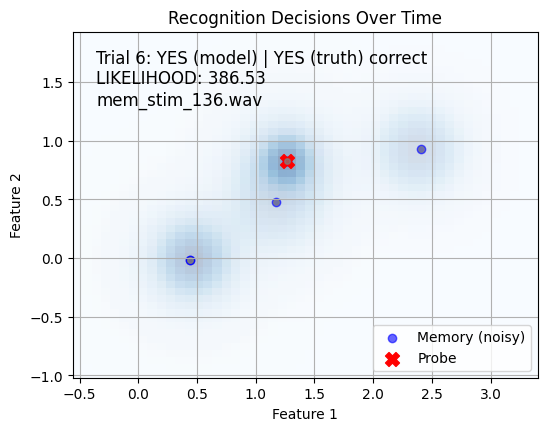

In [11]:
memory_model.animate_trials(save_path = "../movies/tests/likelihood-model/ex.gif")

In [46]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

probe_reps = []
memory_snapshots = []
decisions = []

memory_model.clear_memory()

example_trials = [sounds_list[0],
                  sounds_list[1],
                  sounds_list[2],
                  sounds_list[3],
                  sounds_list[0],
                  sounds_list[1],
                  sounds_list[4],
                  sounds_list[5],
                  sounds_list[6],
                  sounds_list[7],
                  sounds_list[3],
                 ]

for j, path in enumerate(example_trials):
    current_rep = memory_model.encode_sound(path).detach().cpu()
    memory_snapshot = torch.stack(memory_model.memory_bank).detach().cpu() if memory_model.memory_bank else torch.empty(0, current_rep.shape[0])
    
    decision = memory_model(path)
    true_answer = 'YES' if example_trials[j] in example_trials[:j] else 'NO'


    decisions.append(decision.item())


The log-likelihood is -14964.4892578125
The log-likelihood is -2444.648681640625
The log-likelihood is -2854.9013671875
The log-likelihood is -1380.6275634765625
The log-likelihood is -1380.8507080078125
The log-likelihood is -2755.9150390625
The log-likelihood is -2646.2314453125
The log-likelihood is -2811.302978515625
The log-likelihood is -2352.94091796875
The log-likelihood is -1858.7193603515625


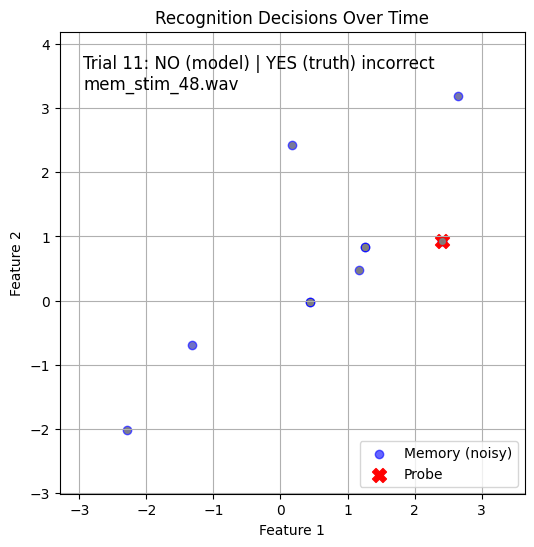

In [47]:
memory_model.animate_trials()